In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

In [3]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

In [4]:
import scanpy as sc
import scmagnify as scm

Jax plugin configuration error: Plugin module jax_plugins.xla_cuda12 does not exist


In [18]:
adata = sc.read("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells110_genes_sigma0.1_5/res.h5ad")

In [19]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth', 'batch', 'n_counts', 'leiden', 'dpt_pseudotime', 'palantir_pseudotime'
    var: 'is_reg', 'is_target'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs', 'base_grn', 'noisy_grn_0.01', 'noisy_grn_0.1', 'noisy_grn_0.5'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [21]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth', 'batch', 'n_counts', 'leiden', 'dpt_pseudotime', 'palantir_pseudotime'
    var: 'is_reg', 'is_target'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs', 'base_grn', 'noisy_grn_0.01', 'noisy_grn_0.1', 'noisy_grn_0.5'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [23]:
noisy_grn = adata.varm["noisy_grn_0.01"].T.copy()

In [20]:
base_grn = adata.varm["base_grn"].T.copy()

In [8]:
base_grn

,gene1,gene2,gene3,gene4,gene5,gene6,gene7,gene8,gene9,gene10,...,gene1241,gene1242,gene1243,gene1244,gene1245,gene1246,gene1247,gene1248,gene1249,gene1250
gene2,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
gene231,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
gene406,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
gene684,1,1,0,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
gene803,1,0,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
gene1004,0,0,0,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
base_grn = scm.utils._matrix_to_edge(base_grn, rownames=base_grn.index, colnames=base_grn.columns)

In [24]:
noisy_grn = scm.utils._matrix_to_edge(noisy_grn, rownames=noisy_grn.index, colnames=noisy_grn.columns)

In [11]:
adata.X

<1000x1250 sparse matrix of type '<class 'numpy.float32'>'
	with 1096876 stored elements in Compressed Sparse Row format>

In [25]:
magni = scm.MAGNI(
            data=adata,
            gene_selected=adata.var_names,
            basal_grn=noisy_grn)

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


        Basal GRN Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric                    ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ n_cells                   │  1000 │
│ n_genes                   │   110 │
│ n_regulators_in_basal_GRN │     6 │
│ n_targets_in_basal_GRN    │    93 │
│ n_regulators_in_both      │     6 │
│ n_targets_in_both         │    93 │
└───────────────────────────┴───────┘

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [26]:
model = magni.train()

Output()

Epoch 00041: reducing learning rate of group 0 to 5.0000e-04.

Epoch 00068: reducing learning rate of group 0 to 2.5000e-04.

Epoch 00082: reducing learning rate of group 0 to 1.2500e-04.

In [27]:
gdata = magni.regulation_inference(cv_thres = None)

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/mudata/_core/mudata.py:491: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 23/224 (0.10)        │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

In [28]:
gdata

Gene Regulatory Network (GRN) with 224 edges.
MuData object with n_obs × n_vars = 1000 × 116
  uns:	'diffmap_evals', 'iroot', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'network', 'filtered_network'
  2 modalities
    RNA:	1000 x 110
      obs:	'cell_id', 'pop', 'depth', 'batch', 'n_counts', 'leiden', 'dpt_pseudotime', 'palantir_pseudotime'
      var:	'is_reg', 'is_target'
      uns:	'diffmap_evals', 'iroot', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'network', 'filtered_network'
      obsm:	'X_diffmap', 'X_pca', 'X_umap'
      varm:	'PCs', 'base_grn', 'noisy_grn_0.01', 'noisy_grn_0.1', 'noisy_grn_0.5'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    GRN:	1000 x 6
      obs:	'cell_id', 'pop', 'depth', 'batch', 'n_counts', 'leiden', 'dpt_pseudotime', 'palantir_pseudotime'
      uns:	'diffmap_evals', 'iroot', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_diffmap', 'X_pca', 'X_umap', 'mlm_estimate', 'mlm_pvals'

In [29]:
edge_df = gdata.uns["network"].iloc[:, 0:3]

In [30]:
edge_df

,TF,Target,score
0,gene91,gene36,0.209324
1,gene6,gene68,0.179850
2,gene6,gene74,0.176211
3,gene6,gene76,0.168982
4,gene6,gene60,0.163666
...,...,...,...
219,gene10,gene59,0.000021
220,gene19,gene34,0.000020
221,gene10,gene1,0.000018
222,gene80,gene94,0.000017


## Batch 

In [50]:
import contextlib

@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            yield

In [54]:
def run_magnify(path, 
                p = 0, 
                seed = 0, 
                output_dir = "/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/net/scMagnify/"
                ):
    
    ds_name = path.split("/")[-2]
    adata = sc.read(os.path.join(path, "res.h5ad"))
    
    if p == 0:
        base_grn = adata.varm["base_grn"].T.copy()
    elif p > 0:
        base_grn = adata.varm[f"noisy_grn_{p}"].T.copy()
        ds_name = ds_name + f"_p{p}"
    else:
        raise ValueError("p must be >= 0")
        
    base_grn = scm.utils._matrix_to_edge(base_grn, rownames=base_grn.index, colnames=base_grn.columns)

    magni = scm.MAGNI(data=adata, gene_selected=adata.var_names, basal_grn=base_grn, seed=seed)
    model = magni.train()
    gdata = magni.regulation_inference(cv_thres=None)
    
    edge_df = gdata.uns["network"].iloc[:, 0:3]
    edge_df.columns = ["TF", "Target", "Score"]
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    edge_df.to_csv(os.path.join(output_dir, f"{ds_name}.csv"), index=None)

In [56]:
run_magnify("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells110_genes_sigma0.1_5/", seed = 3, p = 0.01)

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


        Basal GRN Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric                    ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ n_cells                   │  1000 │
│ n_genes                   │   110 │
│ n_regulators_in_basal_GRN │     6 │
│ n_targets_in_basal_GRN    │    93 │
│ n_regulators_in_both      │     6 │
│ n_targets_in_both         │    93 │
└───────────────────────────┴───────┘

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Output()

Epoch 00057: reducing learning rate of group 0 to 5.0000e-04.

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/mudata/_core/mudata.py:491: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 23/224 (0.10)        │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

In [57]:
ds_dir = "/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/"
datasets = [ds_dir + name + "/" for name in os.listdir(ds_dir) if os.path.isdir(os.path.join(ds_dir, name))]

In [ ]:
from tqdm.auto import tqdm
for dataset in tqdm(datasets, desc=f"Processing datasets: ", unit=f"{datasets[0].split('/')[-2]}"):
    run_magnify(dataset)

In [ ]:
for dataset in tqdm(datasets):
    for p in [0.05]:
        run_magnify(dataset, p=p, seed=42)

## Evaluation

In [31]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")

In [40]:
edge_df

,TF,Target,score
0,gene91,gene36,0.209324
1,gene6,gene68,0.179850
2,gene6,gene74,0.176211
3,gene6,gene76,0.168982
4,gene6,gene60,0.163666
...,...,...,...
219,gene10,gene59,0.000021
220,gene19,gene34,0.000020
221,gene10,gene1,0.000018
222,gene80,gene94,0.000017


In [41]:
true_df = pd.read_csv("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells110_genes_sigma0.1_5/refNetwork.csv", header=0)

In [42]:
true_df

,Gene1,Gene2,Type
0,gene10,gene16,+
1,gene10,gene29,+
2,gene10,gene62,+
3,gene10,gene55,+
4,gene80,gene81,+
...,...,...,...
125,gene19,gene33,+
126,gene19,gene43,+
127,gene19,gene27,+
128,gene19,gene31,+


In [43]:
true_df.columns = ["TF", "Target", "Score"]

In [44]:
true_df = true_df[["TF", "Target"]]

In [45]:
# true_df["TF"] = true_df["TF"].apply(lambda x: x.replace("gene", "gene_"))
# true_df["Target"] = true_df["Target"].apply(lambda x: x.replace("gene", "gene_"))

In [46]:
true_df

,TF,Target
0,gene10,gene16
1,gene10,gene29
2,gene10,gene62
3,gene10,gene55
4,gene80,gene81
...,...,...
125,gene19,gene33
126,gene19,gene43
127,gene19,gene27
128,gene19,gene31


In [47]:
from grn_tools._acc_metrics import evaluate_TFbind, compute_AUPR, compute_Fscore, compute_AUROC

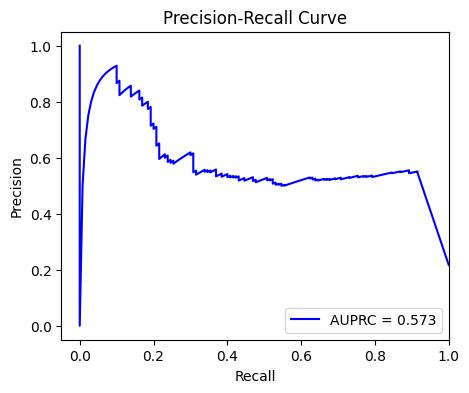

In [48]:
aupr,precs,recalls,auprr1,auprr2 = compute_AUPR(edge_df, true_df, plot=True)

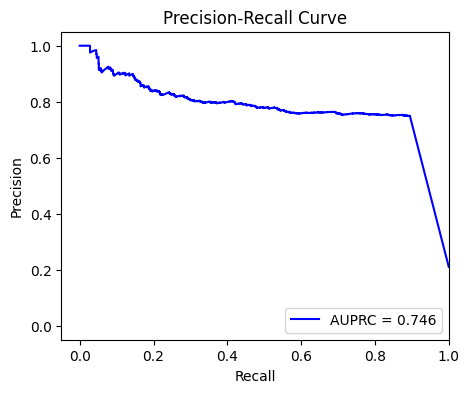

In [27]:
aupr,precs,recalls,auprr1,auprr2 = compute_AUPR(edge_df, true_df, plot=True)

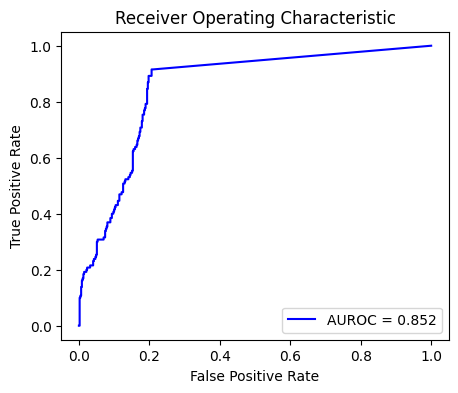

In [49]:
auroc,tprs,fprs = compute_AUROC(edge_df, true_df, plot=True)

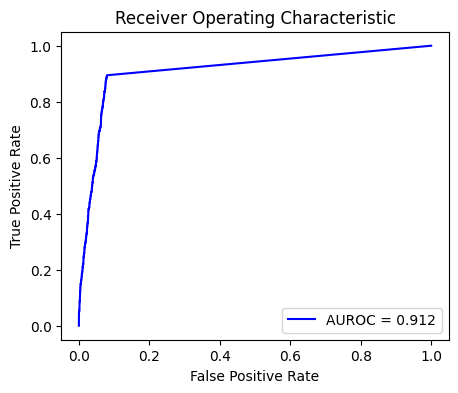

In [38]:
auroc,tprs,fprs = compute_AUROC(edge_df, true_df, plot=True)

In [39]:
auroc

0.9121560520723517

In [29]:
f1,conf_mat,prec,recall,_ = compute_Fscore(edge_df, true_df, beta=1, thres_mode='topk_perTF')

In [30]:
f1

0.8151447661469933

In [8]:
celloracle_df = pd.read_csv("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn1139_noise_tree1_1000_cells1139_genes_sigma0.1_1/celloracle_edge_df.csv", header=0)

In [24]:
celloracle_df2 = pd.read_csv("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/net/CellOracle/grn1139_noise_tree1_1000_cells1139_genes_sigma0.1_1.csv", index_col=None).reset_index(drop=True)

In [25]:
celloracle_df2

,TF,Target,Score
0,gene803,gene1,0.000580
1,gene684,gene1,0.000206
2,gene231,gene1,0.000354
3,gene684,gene10,0.012041
4,gene803,gene10,0.059050
...,...,...,...
1778,gene684,gene996,0.001363
1779,gene803,gene996,0.010326
1780,gene406,gene998,0.036336
1781,gene803,gene999,0.023117


In [23]:
np.unique(celloracle_df2["Target"])

array(['gene1004', 'gene2', 'gene231', 'gene406', 'gene684', 'gene803'],
      dtype=object)

In [32]:
celloracle_df

,TF,Target,Score
0,gene803,gene1,0.000580
1,gene684,gene1,0.000206
2,gene231,gene1,0.000354
3,gene803,gene10,0.059695
4,gene2,gene10,0.008050
...,...,...,...
1778,gene803,gene996,0.010205
1779,gene684,gene996,0.001418
1780,gene406,gene998,0.036336
1781,gene803,gene999,0.023117


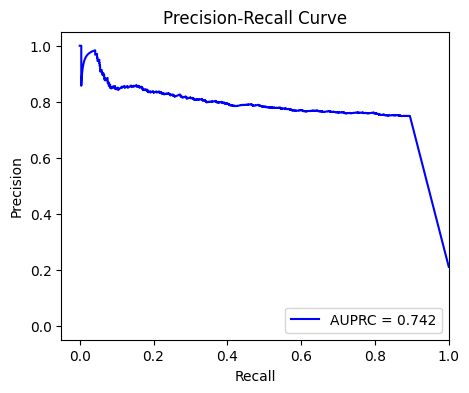

In [19]:
aupr,precs,recalls,auprr1,auprr2 = compute_AUPR(celloracle_df2, true_df, plot=True)

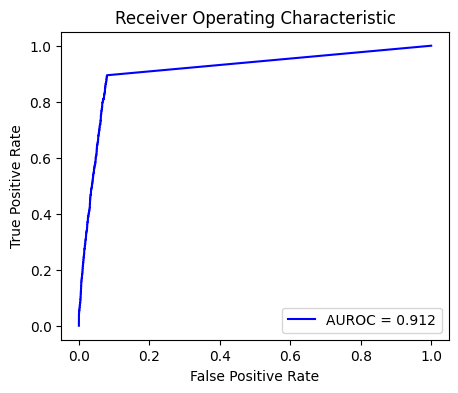

In [34]:
auroc,tprs,fprs = compute_AUROC(celloracle_df, true_df, plot=True)

In [37]:
auroc

0.9123784288435838

In [35]:
f1,conf_mat,prec,recall,_ = compute_Fscore(celloracle_df, true_df, beta=1, thres_mode='topk_perTF')

In [36]:
f1

0.8154042011457671

In [40]:
sin_df = pd.read_csv("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn1139_noise_tree1_1000_cells1139_genes_sigma0.1_1/SINCERITIES.csv", header=0)

In [41]:
sin_df.head()

,TF,Target,Score
0,gene1,gene1,0.000000e+00
1,gene2,gene1,2.603028e-37
2,gene3,gene1,5.944476e-38
3,gene4,gene1,0.000000e+00
4,gene5,gene1,2.364009e-37


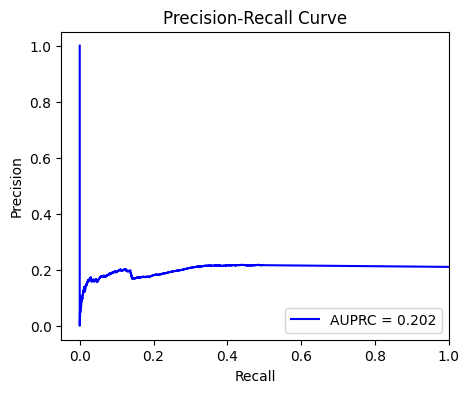

In [42]:
aupr,precs,recalls,auprr1,auprr2 = compute_AUPR(sin_df, true_df, plot=True)

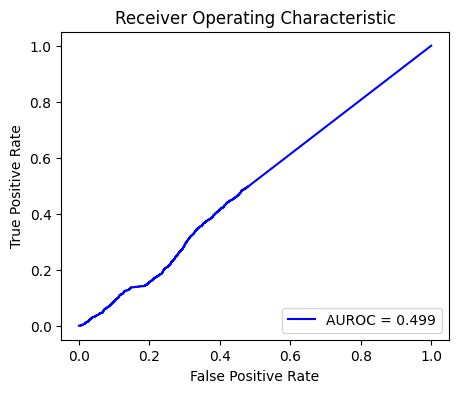

In [43]:
auroc,tprs,fprs = compute_AUROC(sin_df, true_df, plot=True)

In [46]:
f1,conf_mat,prec,recall,_ = compute_Fscore(sin_df, true_df, beta=1, thres_mode='topk_perTF')

In [47]:
f1

0.30109797297297297